In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro

2. For the nobel dataset, find:
(a) Probability of winning a Nobel Prize in Physics given the laureate is female
(b) Probability of winning a Nobel Prize in Literature given the laureate was born in the USA


In [13]:
df2 = pd.read_csv("nobel.csv")
df2.columns

Index(['awardYear', 'category', 'categoryFullName', 'sortOrder', 'portion',
       'prizeAmount', 'prizeAmountAdjusted', 'dateAwarded', 'prizeStatus',
       'motivation', 'categoryTopMotivation', 'award_link', 'id', 'name',
       'knownName', 'givenName', 'familyName', 'fullName', 'penName', 'gender',
       'laureate_link', 'birth_date', 'birth_city', 'birth_cityNow',
       'birth_continent', 'birth_country', 'birth_countryNow',
       'birth_locationString', 'death_date', 'death_city', 'death_cityNow',
       'death_continent', 'death_country', 'death_countryNow',
       'death_locationString', 'orgName', 'nativeName', 'acronym',
       'org_founded_date', 'org_founded_city', 'org_founded_cityNow',
       'org_founded_continent', 'org_founded_country',
       'org_founded_countryNow', 'org_founded_locationString', 'ind_or_org',
       'residence_1', 'residence_2', 'affiliation_1', 'affiliation_2',
       'affiliation_3', 'affiliation_4'],
      dtype='object')

In [14]:
N = len(df2)
count_Physics = len(df2[df2['category'] == 'Physics'])
count_female = len(df2[df2['gender'] == 'female'])
count_physics_given_female = len(df2[(df2['category'] == 'Physics') & (df2['gender'] == 'female')])

P_Physics = count_Physics/N
P_female = count_female/N
P_physics_given_female = count_physics_given_female/count_female

print("Probability of winning a nobel prize in Physics given the laureate is female : ", P_physics_given_female)

Probability of winning a nobel prize in Physics given the laureate is female :  0.05555555555555555


In [15]:
P_female_given_physics = (P_physics_given_female * P_female)/P_Physics
print("Probability of being a female given that winning category is Physics :", P_female_given_physics)

Probability of being a female given that winning category is Physics : 0.014084507042253521


In [16]:
#b)
count_Literature = len(df2[df2['category'] == 'Literature'])
count_Usa = len(df2[df2['birth_country'] == 'USA'])
count_Literature_given_USA = len(df2[(df2['category'] == 'Literature') & (df2['birth_country'] == 'USA')])

P_literature_given_Usa = count_Literature_given_USA/count_Usa
P_literature_given_Usa

0.032846715328467155

In [17]:
P_Literature = count_Literature/N
P_Usa = count_Usa/N
P_usa_given_literature = (P_literature_given_Usa * P_Usa) / P_Literature
P_usa_given_literature

0.07758620689655173

3. Combine datasets:
Men ODI Team Match Results - 20th Century.csv
Men ODI Team Match Results - 21st Century.csv

Find the historical win rate of India.
Now India is scheduled to play 60 ODI matches over the next 3 years.

(a) What is the probability that India wins exactly 35 out of these 60 matches?
(b) What is the probability that India wins more than 40 matches?
(c) What is the probability that India wins at least 45 matches?
(d) What is the most likely number of wins India will have in 60 matches?


In [3]:
df_20 = pd.read_csv("century20.csv")
df_21 = pd.read_csv("century21.csv")
print("Century 20 : ", "\n", df_20.head(2))
print("Century 21 : ", "\n", df_21.head(2))

Century 20 :  
   Result     Margin                Match Home/Away      Ground  Match Date  \
0   Lost  5 wickets  Australia v England      Away   Melbourne  1971/01/05   
1    Won  6 wickets  England v Australia      Home  Manchester  1972/08/24   

  Match Month  Match Year Match Period  Matches  Country  
0         Jan        1971     Jan 1971        1  England  
1         Aug        1972     Aug 1972        1  England  
Century 21 :  
   Result     Margin                Match Home/Away         Ground  Match Date  \
0   Lost  5 wickets  Sri Lanka v England      Away       Dambulla  2001/03/23   
1   Lost    66 runs  Sri Lanka v England      Away  Colombo (RPS)  2001/03/25   

  Match Month  Match Year Match Period  Matches  Country  
0         Mar        2001     Mar 2001        1  England  
1         Mar        2001     Mar 2001        1  England  


In [4]:
df1 = pd.concat([df_20, df_21])
df1.head(2)

,Result,Margin,Match,Home/Away,Ground,Match Date,Match Month,Match Year,Match Period,Matches,Country
0,Lost,5 wickets,Australia v England,Away,Melbourne,1971/01/05,Jan,1971,Jan 1971,1,England
1,Won,6 wickets,England v Australia,Home,Manchester,1972/08/24,Aug,1972,Aug 1972,1,England


In [6]:
from scipy.stats import binom

total_match = len(df1[(df1['Country'] == "India") & (df1['Result'].isin(["Won", "Lost","Tied"]))])
won_match = len(df1[(df1['Country'] == "India") & (df1['Result'] == "Won")])
win_rate = won_match/total_match
loss_rate = 1 - win_rate
print(win_rate)
#a)What is the probability that india win exactly 35 out of these 60 matches ?
n =60
p_a = binom.pmf(35, n, win_rate)
print("Probability of india win exactly 35 out of these 60 matches :", p_a)

#b)What is the probability that india will win more than 40 matches ?
p_b = binom.cdf(60,60,win_rate) - binom.cdf(40,60,win_rate)
print("Probability that India will win more than 40 matches : ", p_b)

#c)What is the probability that india wins at least 45 matches?
p_c = binom.pmf(45,60,win_rate)
print("probability that india wins at least 45 matches : ", p_c)

#d)What is the most likely number of wins India will have in 60 matches?
matches = pd.Series(np.arange(0, n+1))
pmf_values = matches.apply(lambda x: binom.pmf(x, n, win_rate))
most_likely_wins = matches.iloc[pmf_values.idxmax()]  # now works
print("Most likely number of wins:", most_likely_wins)

0.5422832980972516
Probability of india win exactly 35 out of these 60 matches : 0.08474879381709416
Probability that India will win more than 40 matches :  0.01850513244523444
probability that india wins at least 45 matches :  0.00047314588613136735
Most likely number of wins: 33


4. Calculate Z-scores and do outlier analysis on (a) Glucose column of Diabetes dataset, (b) Billionaiers dataset.


In [7]:
from scipy.stats import zscore
df1 = pd.read_csv('diabetes.csv')
print(df1.columns)
df1.head(2)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [8]:
print('Part - a : Glucose column')
g_mean = df1['Glucose'].mean()
g_std = df1['Glucose'].std()
df1['glucose_zscore'] = zscore(df1['Glucose'])
threshold = 3
glucose_outliers = df1[df1['glucose_zscore'].abs() > threshold]

print(glucose_outliers['glucose_zscore'].drop_duplicates())

Part - a : Glucose column
75   -3.783654
Name: glucose_zscore, dtype: float64


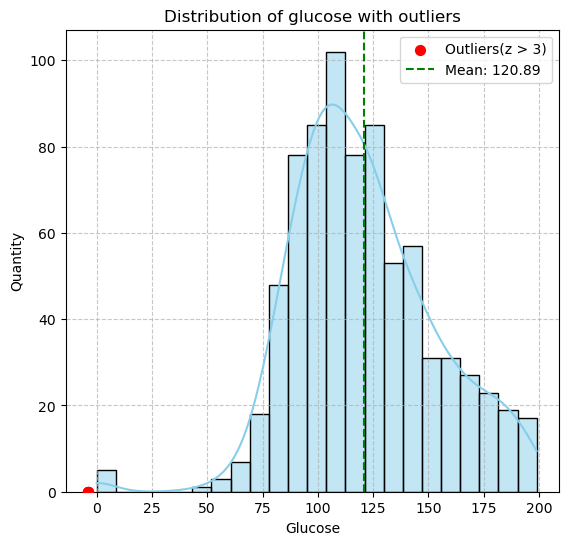

In [10]:
import seaborn as sns
plt.figure(figsize =(14,6))
#plot for glucose outliers
plt.subplot(1,2,1)
sns.histplot(df1['Glucose'], kde = True, color ='skyblue')
plt.scatter(glucose_outliers['glucose_zscore'], [0]*len(glucose_outliers), color = 'red', s = 50, zorder = 5, label = f'Outliers(z > {threshold})')
plt.axvline(g_mean, color='green', linestyle = '--', label = f'Mean: {g_mean:.2f}')
plt.title('Distribution of glucose with outliers')
plt.xlabel('Glucose')
plt.ylabel('Quantity')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)

In [12]:
#b) 
df2= pd.read_csv('billionaires.csv')
df2.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


In [13]:
finalworth_mean = df2['finalWorth'].mean()
finalworth_std = df2['finalWorth'].std()
df2['finalworth_zscore'] = zscore(df2['finalWorth'])

print(f"Mean ={finalworth_mean:.2f}")
print(f"Standard Deviation ={finalworth_std:.2f}")
zscore_threshold = 3

Mean =4623.79
Standard Deviation =9834.24


In [14]:
finalworth_outliers = df2[(df2['finalworth_zscore'].abs() > zscore_threshold)].drop_duplicates()
print(f"Total outliers : {len(finalworth_outliers)}")

Total outliers : 37


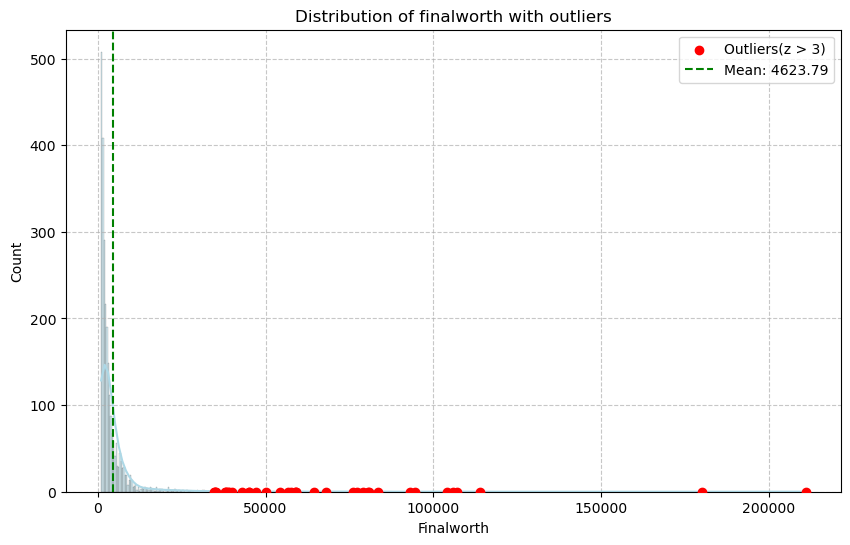

In [15]:
#plot for finalworth outliers
plt.figure(figsize =(10,6))
sns.histplot(df2['finalWorth'], kde = True, color ='lightblue')
plt.scatter(finalworth_outliers['finalWorth'], [0]*len(finalworth_outliers), color = 'red', zorder = 5, label = f'Outliers(z > {zscore_threshold})')
plt.axvline(finalworth_mean, color='green', linestyle = '--', label = f'Mean: {finalworth_mean:.2f}')
plt.title('Distribution of finalworth with outliers')
plt.xlabel('Finalworth')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)

5. For billionaires dataset and titanic age column, first run shapiro test and qq-plot. Then try CLT on both and see if now we see normal distribution for their sample means.


In [4]:
df = pd.read_csv('billionaires.csv')
df.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


In [5]:
age_series = df['age'].dropna()
shapiro_test = stats.shapiro(age_series)
print("Shapiro-Wilk p-value:",shapiro_test.pvalue)

Shapiro-Wilk p-value: 1.940826099666913e-05


In [6]:
if shapiro_test.pvalue > 0.05:
    print("Data is normally distributed.")
else:
    print("Data is not normally distributed.")

Data is not normally distributed.


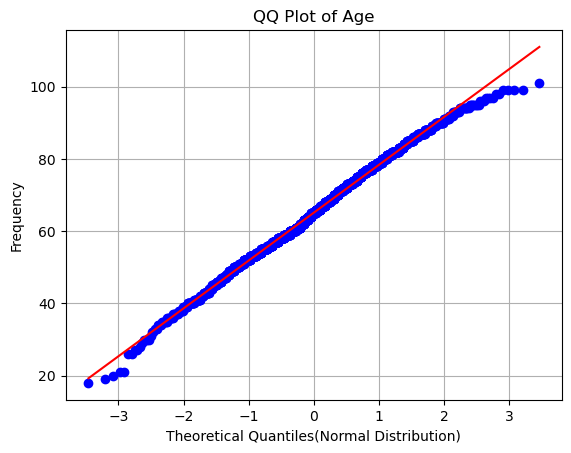

In [7]:
#QQ Plot
stats.probplot(age_series, dist = "norm", plot =plt)
plt.title("QQ Plot of Age")
plt.xlabel("Theoretical Quantiles(Normal Distribution)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

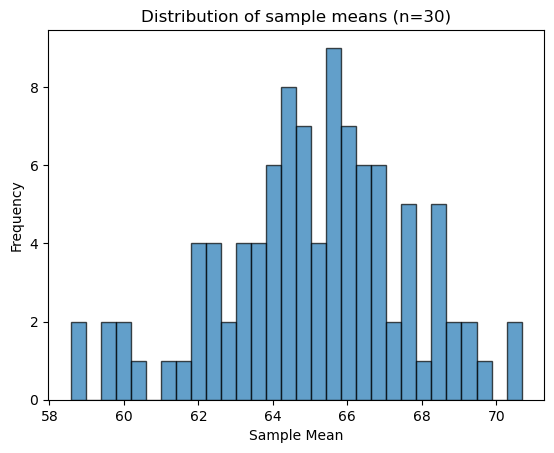

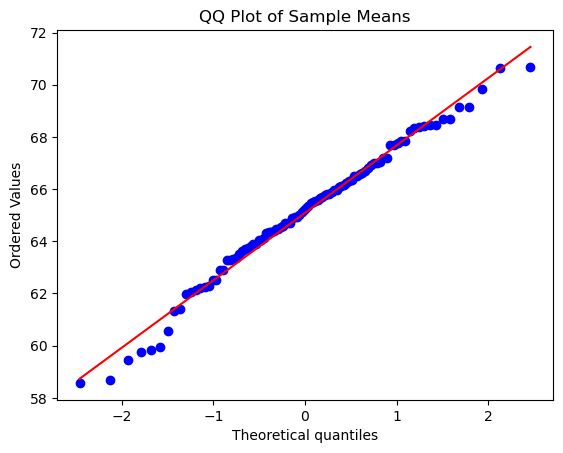

Shapiro-Wilk p-value: 0.35447733854265495
Data is normally distributed


In [8]:
#central Limit Theorem
sample_means = []
n_sample = 100
sample_size = 30

for _ in range(n_sample):
    sample = df['age'].sample(n=sample_size, replace = True)
    sample_means.append(sample.mean())

#plot the  distribution of sample means
plt.hist(sample_means, bins=30, edgecolor = 'k', alpha =0.7)
plt.title("Distribution of sample means (n=30)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

#Qq Plot of sample mean
stats.probplot(sample_means, dist = "norm", plot =plt)
plt.title("QQ Plot of Sample Means")
plt.show()

#Shapiro wilk test on sample means
shapiro_test1= stats.shapiro(sample_means)
print("Shapiro-Wilk p-value:",shapiro_test1.pvalue)
if shapiro_test1.pvalue < 0.05:
    print("Data is NOT normally distributed")
else:
    print("Data is normally distributed")

In [9]:
#Shapiro wilk test on sample means
shapiro_test1= stats.shapiro(sample_means)
print("Shapiro-Wilk p-value:",shapiro_test1.pvalue)
if shapiro_test1.pvalue < 0.05:
    print("Data is NOT normally distributed")
else:
    print("Data is normally distributed")

Shapiro-Wilk p-value: 0.35447733854265495
Data is normally distributed


In [10]:
df1 = pd.read_csv('titanic.csv')
df1.head(2)

,survived,pclass,gender,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C


In [11]:
#Shapiro wilk test on titanic['age'] : population data

age = df1['age'].dropna()
titanic_sample_test = stats.shapiro(age)
titanic_p_value = titanic_sample_test.pvalue
print("Shapiro Wilk test p-value : ", titanic_p_value)

alpha = 0.05
if titanic_p_value > alpha :
    print("Data is normally distributed.")
else : 
    print("Data is NOT normally distributed.")

Shapiro Wilk test p-value :  7.337348958673594e-08
Data is NOT normally distributed.


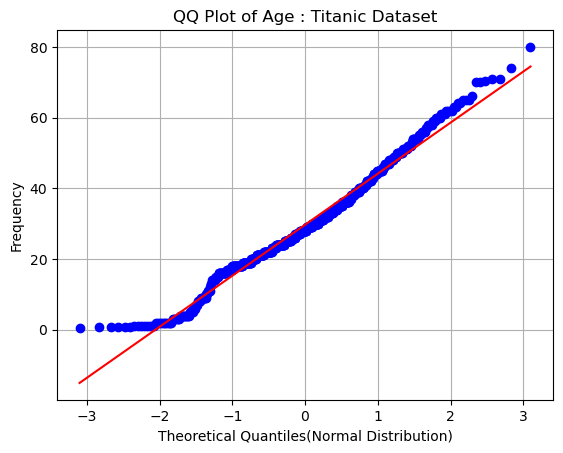

In [12]:
#QQ Plot - titanic['age'] : population data
stats.probplot(age, dist = "norm", plot =plt)
plt.title("QQ Plot of Age : Titanic Dataset")
plt.xlabel("Theoretical Quantiles(Normal Distribution)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()